In [1]:
import torch
import yaml
import numpy as np
import imageio.v2 as imageio
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

from utils.dataset_helper import create_dataloaders
from utils.image_utils import render
from utils.diffusion_data_helper import denormalize_data
from utils.gaussian_file_helper import load_gaussians
from vae_model import GaussianVAE

device = "cuda" if torch.cuda.is_available() else "cpu"
config_path = "config/vae_training_mw.yaml"
checkpoint_path = "checkpoints/best_ffhq.pth"

with open(config_path, "r") as f:
        cfg = yaml.safe_load(f)

In [2]:
model = GaussianVAE(
            num_gaussians=cfg["model"]["num_gaussians"],
            input_dim=cfg["model"]["input_dim"],
            latent_dim=cfg["model"]["model_dim"],
            decoder_layers=cfg["model"].get("decoder_transformer_layers", 6),
            decoder_heads=cfg["model"].get("decoder_transformer_heads", 8)
        ).to(device)

data_loader, _ = create_dataloaders(
    "./data/FFHQ",
    batch_size=1, 
    shuffle=True, 
    augment=False,
    is_distributed=False
)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

Found 70000 files in ./data/FFHQ


GaussianVAE(
  (sa1): PointNetSetAbstractionMsg(
    (conv_blocks): ModuleList(
      (0): ModuleList(
        (0): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
        (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      )
      (1): ModuleList(
        (0): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (2): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      )
      (2): ModuleList(
        (0): Conv2d(8, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1))
        (2): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (bn_blocks): ModuleList(
      (0): ModuleList(
        (0-1): 2 x BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
   

In [3]:
# Video parameters
fps = 30
duration = 5  # seconds
num_frames = fps * duration

# Output path
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
video_path = os.path.join(output_dir, "latent_interpolation.mp4")

print(f"Generating {num_frames} frames for {duration}s video at {fps} fps...")

# Path-aware iterator so the preview cell can display the file ID
import random as _rng
_ds = data_loader.dataset
_shuffled_idx = list(range(len(_ds)))
_rng.shuffle(_shuffled_idx)
_idx_iter = iter(_shuffled_idx)

def data_iter():
    """Returns (batch_tensor, filename) for the next shuffled sample."""
    idx = next(_idx_iter)
    tensor = _ds[idx].unsqueeze(0).to(device)
    name = os.path.basename(_ds.file_paths[idx])
    return tensor, name

Generating 150 frames for 5s video at 30 fps...


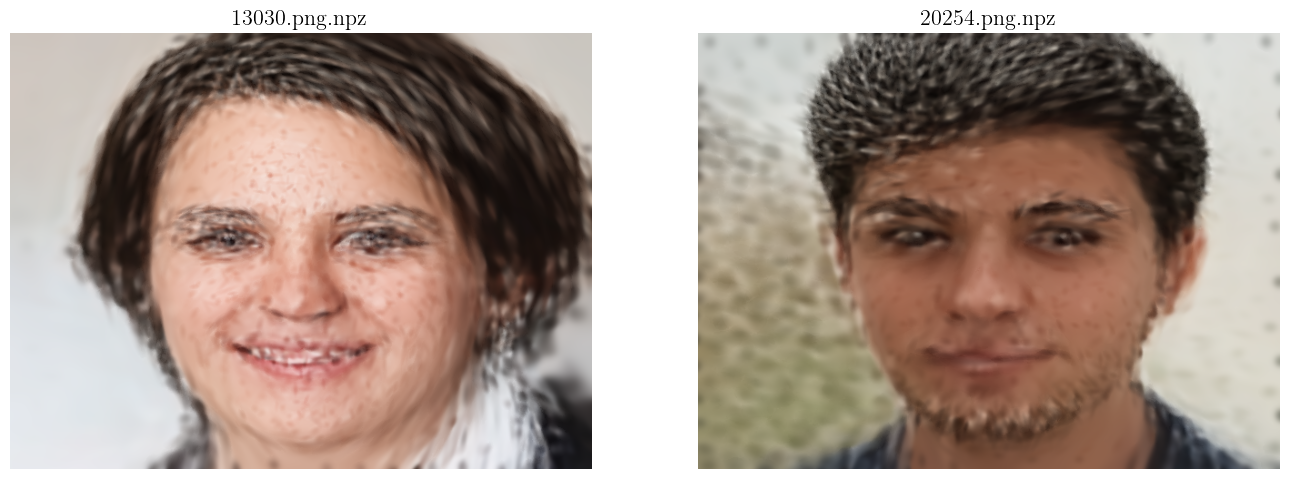

In [59]:
data1, id1 = data_iter()
data2, id2 = data_iter()

# Encode to get latent means (kept as module-level vars for the video cell below)
with torch.no_grad():
    mu1, logvar1 = model.encode(data1)
    mu2, logvar2 = model.encode(data2)

# Quick preview — re-run this cell to sample a new pair
def _render_encoded(mu):
    with torch.no_grad():
        decoded = model.decode(mu)
    xy, scale, rot, feat = denormalize_data(decoded[:, :, 0:2], decoded[:, :, 2:4],
                                            decoded[:, :, 4:5], decoded[:, :, 5:8])
    img = render(xy.squeeze(0).contiguous().float(),
                 scale.squeeze(0).contiguous().float(),
                 rot.squeeze(0).contiguous().float(),
                 feat.squeeze(0).contiguous().float(),
                 img_size=(480, 640))
    return img.cpu().detach().permute(1, 2, 0).numpy()

img1 = _render_encoded(mu1)
img2 = _render_encoded(mu2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(np.clip(img1, 0, 1))
axes[0].set_title(id1)
axes[0].axis("off")
axes[1].imshow(np.clip(img2, 0, 1))
axes[1].set_title(id2)
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [60]:
# Run this cell only once you're happy with the two samples above
with imageio.get_writer(video_path, fps=fps, format="FFMPEG", codec="libx264", quality=8) as writer:
    for i in tqdm(range(num_frames)):
        alpha = i / (num_frames - 1)
        latent_interp = (1 - alpha) * mu1 + alpha * mu2

        with torch.no_grad():
            decoded = model.decode(latent_interp)

        xy, scale, rot, feat = denormalize_data(decoded[:, :, 0:2], decoded[:, :, 2:4],
                                                decoded[:, :, 4:5], decoded[:, :, 5:8])

        xy = xy.squeeze(0).contiguous().float()
        scale = scale.squeeze(0).contiguous().float()
        rot = rot.squeeze(0).contiguous().float()
        feat = feat.squeeze(0).contiguous().float()

        image = render(xy, scale, rot, feat, img_size=(int(480), int(640)))
        image_np = image.cpu().detach().permute(1, 2, 0).numpy()
        writer.append_data((np.clip(image_np, 0, 1) * 255).astype(np.uint8))

print(f"Video saved to {video_path}")

100%|██████████| 150/150 [00:16<00:00,  9.30it/s]


Video saved to output/latent_interpolation.mp4


In [61]:
# Let's also save an interpolation as a series of images for reference, using the 2 extremes 3 frames in between
image_output_dir = os.path.join(output_dir, "interpolation_frames")
os.makedirs(image_output_dir, exist_ok=True)
num_image_frames = 5
for i in range(num_image_frames):
    alpha = i / (num_image_frames - 1)
    
    latent_interp = (1 - alpha) * mu1 + alpha * mu2
    
    with torch.no_grad():
        decoded = model.decode(latent_interp)
    
    xy, scale, rot, feat = denormalize_data(decoded[:, :, 0:2], decoded[:, :, 2:4], 
                                            decoded[:, :, 4:5], decoded[:, :, 5:8])
    
    xy = xy.squeeze(0).contiguous().float()
    scale = scale.squeeze(0).contiguous().float()
    rot = rot.squeeze(0).contiguous().float()
    feat = feat.squeeze(0).contiguous().float()
    
    img_size = (int(480), int(640))
    image = render(xy, scale, rot, feat, img_size=img_size)
    image_np = image.cpu().detach().permute(1, 2, 0).numpy()
    
    image_uint8 = (np.clip(image_np, 0, 1) * 255).astype(np.uint8)
    imageio.imwrite(os.path.join(image_output_dir, f"frame_{i:02d}.png"), image_uint8)

In [ ]:
# I would like to do a giant render of a single sample, it should be at least 10k by 10k pixels
data_sample = next(data_iter).to(device)
with torch.no_grad():
    mu, logvar = model.encode(data_sample)
    decoded = model.decode(mu)

    xy, scale, rot, feat = denormalize_data(decoded[:, :, 0:2], decoded[:, :, 2:4],
                                            decoded[:, :, 4:5], decoded[:, :, 5:8])
    
    xy = xy.squeeze(0).contiguous().float()
    scale = scale.squeeze(0).contiguous().float()
    rot = rot.squeeze(0).contiguous().float()
    feat = feat.squeeze(0).contiguous().float()

    img_size = (4800, 6400)
    large_image = render(xy, scale * 10.0, rot, feat, img_size=img_size)
    large_image_np = large_image.cpu().detach().permute(1, 2, 0).numpy()
    large_image_uint8 = (np.clip(large_image_np, 0, 1) * 255).astype(np.uint8)
    large_image_path = os.path.join(output_dir, "large_render.png")
    imageio.imwrite(large_image_path, large_image_uint8)

    img_size = (480, 640)
    small_image = render(xy, scale, rot, feat, img_size=img_size)
    small_image_np = small_image.cpu().detach().permute(1, 2, 0).numpy()
    small_image_uint8 = (np.clip(small_image_np, 0, 1) * 255).astype(np.uint8)
    small_image_path = os.path.join(output_dir, "small_render.png")
    imageio.imwrite(small_image_path, small_image_uint8)

    #Let's print out which inputs we used
    print("Used the following two samples for interpolation:")
    print(data_sample)
    print(f"Small render saved to {small_image_path}")
    print(f"Giant render saved to {large_image_path}")

In [11]:
#Let's render every single npz in the data folder and save the images to a folder
render_output_dir = os.path.join(output_dir, "all_renders")
os.makedirs(render_output_dir, exist_ok=True)
data_filenames = sorted([f for f in os.listdir("./data/FFHQ_subset") if f.endswith(".npz")])
print(f"Rendering {len(data_filenames)} files to {render_output_dir}...")
print(data_filenames[0])

Rendering 5000 files to output/all_renders...
00000.png.npz


In [12]:
for filename in tqdm(data_filenames):
    data_path = os.path.join("./data/FFHQ_subset", filename)
    if os.path.exists(os.path.join(render_output_dir, "gt",f"{os.path.splitext(filename)[0]}_render_gt.png")):
        continue  #Skip already rendered files

    data =  load_gaussians(data_path)
    xy = data['xy'].unsqueeze(0).to(device)
    scale = data['scale'].unsqueeze(0).to(device) 
    rot = data['rot'].unsqueeze(0).to(device)
    feat = data['feat'].unsqueeze(0).to(device)
    input_data = torch.cat([xy, scale, rot, feat], dim=2)

    #Render ground truth
    image_gt = render(xy.squeeze(0), scale.squeeze(0)/2, rot.squeeze(0), feat.squeeze(0), img_size=(256, 256))
    image_gt_np = image_gt.cpu().detach().permute(1, 2, 0).numpy()
    image_gt_uint8 = (np.clip(image_gt_np, 0, 1) * 255).astype(np.uint8)
    
    output_image_path_gt = os.path.join(render_output_dir, "gt",f"{os.path.splitext(filename)[0]}_render_gt.png")
    imageio.imwrite(output_image_path_gt, image_gt_uint8)

100%|██████████| 5000/5000 [01:52<00:00, 44.62it/s]  


In [13]:
#Render VAE reconstruction
from utils.dataset_helper import GaussianSplatDataset
from torch.utils.data import DataLoader

# Create dataset ensuring order matches data_filenames
file_paths = [os.path.join("./data/FFHQ_subset", f) for f in data_filenames]
dataset = GaussianSplatDataset("./data/FFHQ", file_paths=file_paths, augment=False)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

for (filename, input_data) in tqdm(zip(data_filenames, loader), total=len(data_filenames)):
    
    if os.path.exists(os.path.join(render_output_dir, "vae",f"{os.path.splitext(filename)[0]}_render_vae.png")):
        continue  #Skip already rendered files

    with torch.no_grad():
        input_data = input_data.to(device)
        mu, logvar = model.encode(input_data)
        decoded = model.decode(mu)

        xy_dec, scale_dec, rot_dec, feat_dec = denormalize_data(decoded[:, :, 0:2], decoded[:, :, 2:4],
                                                decoded[:, :, 4:5], decoded[:, :, 5:8])
        
        xy_dec = xy_dec.squeeze(0).contiguous().float()
        scale_dec = scale_dec.squeeze(0).contiguous().float()
        rot_dec = rot_dec.squeeze(0).contiguous().float()
        feat_dec = feat_dec.squeeze(0).contiguous().float()

        image_vae = render(xy_dec, scale_dec/2, rot_dec, feat_dec, img_size=(256, 256))
        image_vae_np = image_vae.cpu().detach().permute(1, 2, 0).numpy()
        image_vae_uint8 = (np.clip(image_vae_np, 0, 1) * 255).astype(np.uint8)
        
        output_image_path_vae = os.path.join(render_output_dir, "vae", f"{os.path.splitext(filename)[0]}_render_vae.png")
        imageio.imwrite(output_image_path_vae, image_vae_uint8)

100%|██████████| 5000/5000 [19:01<00:00,  4.38it/s]


In [14]:
# Let's calculate the FID and KID between the GT renders and the VAE renders
import os
import time
# First we split the images into two folders
gt = 0
os.makedirs(os.path.join(render_output_dir, "gt_renders"), exist_ok=True)
vae = 0
os.makedirs(os.path.join(render_output_dir, "vae_renders"), exist_ok=True)


for i in os.listdir(render_output_dir):
    if i.endswith("_render_gt.png"):
        os.rename(os.path.join(render_output_dir, i), os.path.join(render_output_dir, "gt_renders", i))
        gt += 1
    elif i.endswith("_render_vae.png"):
        os.rename(os.path.join(render_output_dir, i), os.path.join(render_output_dir, "vae_renders", i))
        vae += 1
    else:
        print(f"Unknown file in render output dir: {i}")
        continue

print(f"Calculating FID and KID between {gt} GT renders and {vae} VAE renders...")

from cleanfid import fid
print("Computing FID and KID, this may take a while...")
start_time =  time.time()
fid_value = fid.compute_fid(os.path.join(render_output_dir, "gt"),
                            os.path.join(render_output_dir, "vae"),
                            mode="clean",
                            num_workers=16)
end_time = time.time()
print(f"FID computation took {end_time - start_time:.2f} seconds.")
print(f"FID: {fid_value}")

start_time =  time.time()
kid_value = fid.compute_kid(os.path.join(render_output_dir, "gt"),
                            os.path.join(render_output_dir, "vae"),
                            mode="clean",
                            num_workers=16)
end_time = time.time()
print(f"KID computation took {end_time - start_time:.2f} seconds.")
print(f"KID: {kid_value}")



Unknown file in render output dir: gt
Unknown file in render output dir: gt_renders
Unknown file in render output dir: vae
Unknown file in render output dir: vae_renders
Calculating FID and KID between 0 GT renders and 0 VAE renders...
Computing FID and KID, this may take a while...
compute FID between two folders
Found 5000 images in the folder output/all_renders/gt


FID gt : 100%|██████████| 157/157 [00:08<00:00, 19.21it/s]


Found 5000 images in the folder output/all_renders/vae


FID vae : 100%|██████████| 157/157 [00:07<00:00, 22.39it/s]


FID computation took 21.19 seconds.
FID: 97.29770188594472
compute KID between two folders
Found 5000 images in the folder output/all_renders/gt


KID gt : 100%|██████████| 157/157 [00:06<00:00, 22.79it/s]


Found 5000 images in the folder output/all_renders/vae


KID vae : 100%|██████████| 157/157 [00:07<00:00, 20.68it/s]


KID computation took 19.30 seconds.
KID: 0.09299369156360626


In [ ]:
print(f"KID: {kid_value}")

In [15]:
import time
import numpy as np
from PIL import Image
from tqdm import tqdm
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import lpips as lpips_lib

gt_dir  = os.path.join(render_output_dir, "gt")
vae_dir = os.path.join(render_output_dir, "vae")

# Match pairs by stripping per-side suffix
gt_map  = {f.replace("_render_gt.png",  ""): f for f in os.listdir(gt_dir)  if f.endswith("_render_gt.png")}
vae_map = {f.replace("_render_vae.png", ""): f for f in os.listdir(vae_dir) if f.endswith("_render_vae.png")}
keys = sorted(gt_map.keys() & vae_map.keys())
print(f"Matched {len(keys)} image pairs for PSNR / SSIM / LPIPS")

psnr_fn  = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_fn  = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
lpips_fn = lpips_lib.LPIPS(net="alex").to(device)

BATCH = 64

def _load(path):
    return torch.from_numpy(
        np.array(Image.open(path)).astype(np.float32) / 255.0
    ).permute(2, 0, 1)  # [C, H, W]

psnr_scores, ssim_scores, lpips_scores = [], [], []

t0 = time.time()
for i in tqdm(range(0, len(keys), BATCH)):
    batch_keys = keys[i : i + BATCH]
    gt_batch  = torch.stack([_load(os.path.join(gt_dir,  gt_map[k]))  for k in batch_keys]).to(device)
    vae_batch = torch.stack([_load(os.path.join(vae_dir, vae_map[k])) for k in batch_keys]).to(device)

    with torch.no_grad():
        for gt_img, vae_img in zip(gt_batch, vae_batch):
            g, v = gt_img.unsqueeze(0), vae_img.unsqueeze(0)
            psnr_scores.append(psnr_fn(v, g).item())
            ssim_scores.append(ssim_fn(v, g).item())

        # LPIPS expects images in [-1, 1]
        scores = lpips_fn(vae_batch * 2 - 1, gt_batch * 2 - 1).squeeze().cpu()
        lpips_scores.extend(scores.tolist() if scores.dim() > 0 else [scores.item()])

print(f"\nComputed over {len(keys)} pairs in {time.time() - t0:.1f}s")
print(f"PSNR:  {np.mean(psnr_scores):.4f} ± {np.std(psnr_scores):.4f} dB")
print(f"SSIM:  {np.mean(ssim_scores):.4f} ± {np.std(ssim_scores):.4f}")
print(f"LPIPS: {np.mean(lpips_scores):.4f} ± {np.std(lpips_scores):.4f}")

Matched 5000 image pairs for PSNR / SSIM / LPIPS
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/gijsf/miniconda3/envs/gsplat/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/gijsf/miniconda3/envs/gsplat/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/gijsf/miniconda3/envs/gsplat/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 79/79 [00:36<00:00,  2.18it/s]


Computed over 5000 pairs in 36.2s
PSNR:  18.9986 ± 1.5023 dB
SSIM:  0.5114 ± 0.0877
LPIPS: 0.3051 ± 0.0603
